In [ ]:
# additional imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [ ]:
# Load in the data
fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x_train.shape:", x_train.shape)

x_train.shape: (60000, 28, 28)


In [ ]:
# the data is only 2D since its a grayscale image
# convolution expects height x width x color
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print(x_train.shape)

(60000, 28, 28, 1)


In [ ]:
# number of classes
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [ ]:
# Build the model using the functional API
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [ ]:
# Compile and fit
# Note: make sure you are using the GPU for this!
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 [==============================] - 35s 18ms/step - loss: 0.5219 - accuracy: 0.8077 - val_loss: 0.4144 - val_accuracy: 0.8487
Epoch 2/15
1875/1875 [==============================] - 33s 18ms/step - loss: 0.3614 - accuracy: 0.8647 - val_loss: 0.3548 - val_accuracy: 0.8675
Epoch 3/15
1875/1875 [==============================] - 33s 18ms/step - loss: 0.3092 - accuracy: 0.8842 - val_loss: 0.3204 - val_accuracy: 0.8798
Epoch 4/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.2799 - accuracy: 0.8948 - val_loss: 0.3047 - val_accuracy: 0.8899
Epoch 5/15
1875/1875 [==============================] - 32s 17ms/step - loss: 0.2495 - accuracy: 0.9050 - val_loss: 0.3005 - val_accuracy: 0.8891
Epoch 6/15
1875/1875 [==============================] - 33s 18ms/step - loss: 0.2322 - accuracy: 0.9115 - val_loss: 0.2970 - val_accuracy: 0.8943
Epoch 7/15
1875/1875 [==============================] - 33s 18ms/step - loss: 0.2136 - accuracy: 0.9192 - val_loss: 0.2999 -

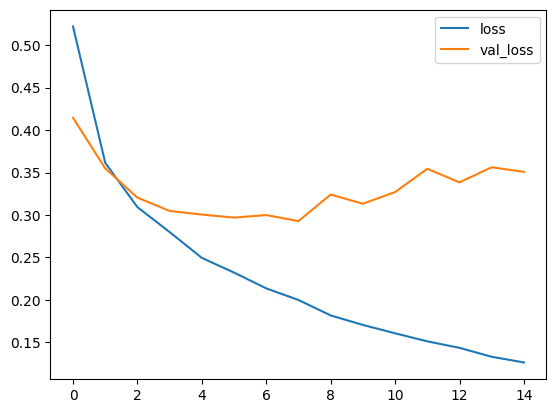

In [ ]:
# Plot loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

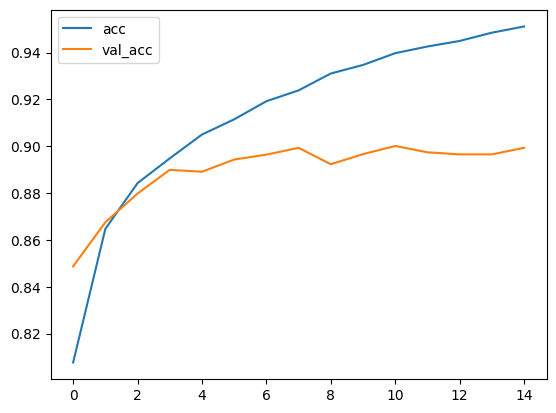

In [ ]:
# Plot accuracy per iteration
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()